# Artificial Intelligence Nanodegree
## Recurrent Neural Network Projects

Welcome to the Recurrent Neural Network Project in the Artificial Intelligence Nanodegree! In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

### Implementation TODOs in this notebook

This notebook contains two problems, cut into a variety of TODOs.  Make sure to complete each section containing a TODO marker throughout the notebook.  For convinence we provide links to each of these sections below.

[TODO #1: Implement a function to window time series](#TODO_1)

[TODO #2: Create a simple RNN model using keras to perform regression](#TODO_2)

[TODO #3: Finish cleaning a large text corpus](#TODO_3)

[TODO #4: Implement a function to window a large text corpus](#TODO_4)

[TODO #5: Create a simple RNN model using keras to perform multiclass classification](#TODO_5)

[TODO #6: Generate text using a fully trained RNN model and a variety of input sequences](#TODO_6)


# Problem 1: Perform time series prediction 

In this project you will perform time series prediction using a Recurrent Neural Network regressor.  In particular you will re-create the figure shown in the notes - where the stock price of Apple was forecasted (or predicted) 7 days in advance.  In completing this exercise you will learn how to construct RNNs using Keras, which will also aid in completing the second project in this notebook.

The particular network architecture we will employ for our RNN is known as  [Long Term Short Memory (LTSM)](https://en.wikipedia.org/wiki/Long_short-term_memory), which helps significantly avoid technical problems with optimization of RNNs.  

## 1.1 Getting started

First we must load in our time series - a history of around 140 days of Apple's stock price.  Then we need to perform a number of pre-processing steps to prepare it for use with an RNN model.  First off, it is good practice to normalize time series - by normalizing its range.  This helps us avoid serious numerical issues associated how common activation functions (like tanh) transform very large (positive or negative) numbers, as well as helping us to avoid related issues when computing derivatives.

Here we normalize the series to lie in the range [0,1] [using this scikit function](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html), but it is also commonplace to normalize by a series standard deviation.

In [1]:
### Load in necessary libraries for data input and normalization
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [130]:
### load in and normalize the dataset
dataset = pd.read_csv('normalized_apple_prices.csv',header=None).values
dataset

array([[-0.70062339],
       [-0.82088484],
       [-0.93938305],
       [-0.9471652 ],
       [-0.68785527],
       [-0.84325902],
       [-0.80532018],
       [-0.82058073],
       [-0.92023124],
       [-1.        ],
       [-0.98814438],
       [-0.85961411],
       [-0.8706188 ],
       [-0.92661512],
       [-0.80118585],
       [-0.76288204],
       [-0.66499478],
       [-0.67289882],
       [-0.68220115],
       [-0.542119  ],
       [-0.46508592],
       [-0.21489592],
       [-0.17020823],
       [-0.08247456],
       [ 0.06411336],
       [ 0.0857576 ],
       [ 0.38604654],
       [ 0.39468034],
       [ 0.40708331],
       [ 0.55482607],
       [ 0.4571212 ],
       [ 0.217267  ],
       [ 0.38258092],
       [ 0.16187873],
       [ 0.16838432],
       [-0.00227998],
       [ 0.21903043],
       [ 0.16187873],
       [ 0.3212949 ],
       [ 0.21939484],
       [ 0.2579419 ],
       [ 0.30311627],
       [ 0.42818056],
       [ 0.42708622],
       [ 0.36190893],
       [ 0

Lets take a quick look at the (normalized) time series we'll be performing predictions on.

Text(0, 0.5, 'normalized series value')

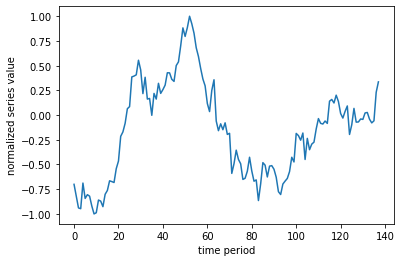

In [131]:
# lets take a look at our time series
plt.plot(dataset)
plt.xlabel('time period')
plt.ylabel('normalized series value')

## 1.2  Cutting our time series into sequences

Remember, our time series is a sequence of numbers that we can represent in general mathematically as 

$$s_{0},s_{1},s_{2},...,s_{P}$$

where $s_{p}$ is the numerical value of the time series at time period $p$ and where $P$ is the total length of the series.  In order to apply our RNN we treat the time series prediction problem as a regression problem, and so need to use a sliding window to construct a set of associated input/output pairs to regress on.  This process is animated in the gif below.

<img src="images/timeseries_windowing_training.gif" width=600 height=600/>

For example - using a window of size T = 5 (as illustrated in the gif above) we produce a set of input/output pairs like the one shown in the table below

$$\begin{array}{c|c}
\text{Input} & \text{Output}\\
\hline \color{CornflowerBlue} {\langle s_{1},s_{2},s_{3},s_{4},s_{5}\rangle} & \color{Goldenrod}{ s_{6}} \\
\ \color{CornflowerBlue} {\langle s_{2},s_{3},s_{4},s_{5},s_{6} \rangle } & \color{Goldenrod} {s_{7} } \\
\color{CornflowerBlue}  {\vdots} & \color{Goldenrod} {\vdots}\\
\color{CornflowerBlue} { \langle s_{P-5},s_{P-4},s_{P-3},s_{P-2},s_{P-1} \rangle } & \color{Goldenrod} {s_{P}}
\end{array}$$

Notice here that each input is a sequence (or vector) of length 4 (and in general has length equal to the window size T) while each corresponding output is a scalar value.  Notice also how given a time series of length P and window size T = 5 as shown above, we created P - 5  input/output pairs.  More generally, for a window size T we create P - T such pairs.

Now its time for you to window the input time series as described above!  

<a id='TODO_1'></a>

**TODO:** Fill in the function below - called **window_transform_series** - that runs a sliding window along the input series and creates associated input/output pairs.    Note that this function should input a) the series and b) the window length, and return the input/output subsequences.  Make sure to format returned input/output as generally shown in table above (where window_size = 5), and make sure your returned input is a numpy array.

-----

Again - you can check that your completed **window_transform_series** function works correctly by trying it on the odd_nums sequence - you should get the above output.  

(remember to copy your completed function into the script *my_answers.py* function titled *window_transform_series* before submitting your project)

-----

In [132]:
def window_transform_series(series,window_size):
    # containers for input/output pairs
    X = []
    y = []
    for i in range(len(series)-window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    
        
    # reshape each 
    X = np.asarray(X)
    X.shape = (np.shape(X)[0:2])
    y = np.asarray(y)
    y.shape = (len(y),1)
    
    return X,y

With this function in place apply it to the series in the Python cell below.  We use a window_size = 7 for these experiments.

In [133]:
# window the data using your windowing function
window_size = 7
X,y = window_transform_series(series=dataset, window_size=window_size)
X

array([[-0.70062339, -0.82088484, -0.93938305, -0.9471652 , -0.68785527,
        -0.84325902, -0.80532018],
       [-0.82088484, -0.93938305, -0.9471652 , -0.68785527, -0.84325902,
        -0.80532018, -0.82058073],
       [-0.93938305, -0.9471652 , -0.68785527, -0.84325902, -0.80532018,
        -0.82058073, -0.92023124],
       [-0.9471652 , -0.68785527, -0.84325902, -0.80532018, -0.82058073,
        -0.92023124, -1.        ],
       [-0.68785527, -0.84325902, -0.80532018, -0.82058073, -0.92023124,
        -1.        , -0.98814438],
       [-0.84325902, -0.80532018, -0.82058073, -0.92023124, -1.        ,
        -0.98814438, -0.85961411],
       [-0.80532018, -0.82058073, -0.92023124, -1.        , -0.98814438,
        -0.85961411, -0.8706188 ],
       [-0.82058073, -0.92023124, -1.        , -0.98814438, -0.85961411,
        -0.8706188 , -0.92661512],
       [-0.92023124, -1.        , -0.98814438, -0.85961411, -0.8706188 ,
        -0.92661512, -0.80118585],
       [-1.        , -0.9881

## 1.3  Splitting into training and testing sets

In order to perform proper testing on our dataset we will lop off the last 1/3 of it for validation (or testing).  This is that once we train our model we have something to test it on (like any regression problem!).  This splitting into training/testing sets is done in the cell below.

Note how here we are **not** splitting the dataset *randomly* as one typically would do when validating a regression model.  This is because our input/output pairs *are related temporally*.   We don't want to validate our model by training on a random subset of the series and then testing on another random subset, as this simulates the scenario that we receive new points *within the timeframe of our training set*.  

We want to train on one solid chunk of the series (in our case, the first full 2/3 of it), and validate on a later chunk (the last 1/3) as this simulates how we would predict *future* values of a time series.

In [7]:
# split our dataset into training / testing sets
train_test_split = int(np.ceil(2*len(y)/float(3)))   # set the split point

# partition the training set
X_train = X[:train_test_split,:]
y_train = y[:train_test_split]

# keep the last chunk for testing
X_test = X[train_test_split:,:]
y_test = y[train_test_split:]

# NOTE: to use keras's RNN LSTM module our input must be reshaped to [samples, window size, stepsize] 
X_train = np.asarray(np.reshape(X_train, (X_train.shape[0], window_size, 1)))
X_test = np.asarray(np.reshape(X_test, (X_test.shape[0], window_size, 1)))

<a id='TODO_2'></a>

## 1.4  Build and run an RNN regression model

Having created input/output pairs out of our time series and cut this into training/testing sets, we can now begin setting up our RNN.  We use Keras to quickly build a two hidden layer RNN of the following specifications

- layer 1 uses an LSTM module with 5 hidden units (note here the input_shape = (window_size,1))
- layer 2 uses a fully connected module with one unit
- the 'mean_squared_error' loss should be used (remember: we are performing regression here)

This can be constructed using just a few lines - see e.g., the [general Keras documentation](https://keras.io/getting-started/sequential-model-guide/) and the [LTSM documentation in particular](https://keras.io/layers/recurrent/) for examples of how to quickly use Keras to build neural network models.  Make sure you are initializing your optimizer given the [keras-recommended approach for RNNs](https://keras.io/optimizers/) 

(given in the cell below).  (remember to copy your completed function into the script *my_answers.py* function titled *build_part1_RNN* before submitting your project)

In [41]:
### TODO: create required RNN model
# import keras network libraries
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN


# TODO: build an RNN to perform regression on our time series input/output data
model = Sequential()
model.add(SimpleRNN(5, input_shape=(window_size,1)))
model.add(Dense(1))


# build model using keras documentation recommended optimizer initialization
# optimizer = optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08, decay=0.0)

# compile the model
model.compile(loss='mean_squared_error')

In [128]:
model.summary

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_6 (SimpleRNN)    (None, 5)                 35        
                                                                 
 dense_11 (Dense)            (None, 1)                 6         
                                                                 
Total params: 41
Trainable params: 41
Non-trainable params: 0
_________________________________________________________________


With your model built you can now fit the model by activating the cell below!  Note: the number of epochs (np_epochs) and batch_size are preset (so we can all produce the same results).  You can choose to toggle the verbose parameter - which gives you regular updates on the progress of the algorithm - on and off by setting it to 1 or 0 respectively.

In [42]:
# run your model!
hist = model.fit(X_train, y_train, epochs=1000, batch_size=500, verbose=2, validation_split=0.2)

Epoch 1/1000
1/1 - 1s - loss: 0.1396 - val_loss: 0.0816 - 1s/epoch - 1s/step
Epoch 2/1000
1/1 - 0s - loss: 0.1266 - val_loss: 0.0780 - 74ms/epoch - 74ms/step
Epoch 3/1000
1/1 - 0s - loss: 0.1182 - val_loss: 0.0751 - 37ms/epoch - 37ms/step
Epoch 4/1000
1/1 - 0s - loss: 0.1119 - val_loss: 0.0724 - 35ms/epoch - 35ms/step
Epoch 5/1000
1/1 - 0s - loss: 0.1066 - val_loss: 0.0700 - 30ms/epoch - 30ms/step
Epoch 6/1000
1/1 - 0s - loss: 0.1022 - val_loss: 0.0678 - 44ms/epoch - 44ms/step
Epoch 7/1000
1/1 - 0s - loss: 0.0983 - val_loss: 0.0656 - 38ms/epoch - 38ms/step
Epoch 8/1000
1/1 - 0s - loss: 0.0948 - val_loss: 0.0635 - 36ms/epoch - 36ms/step
Epoch 9/1000
1/1 - 0s - loss: 0.0916 - val_loss: 0.0615 - 39ms/epoch - 39ms/step
Epoch 10/1000
1/1 - 0s - loss: 0.0888 - val_loss: 0.0595 - 46ms/epoch - 46ms/step
Epoch 11/1000
1/1 - 0s - loss: 0.0861 - val_loss: 0.0575 - 45ms/epoch - 45ms/step
Epoch 12/1000
1/1 - 0s - loss: 0.0836 - val_loss: 0.0555 - 33ms/epoch - 33ms/step
Epoch 13/1000
1/1 - 0s - loss

## 1.5  Checking model performance

In the next cell we compute training and testing errors using our trained model - you should be able to achieve at least

*training_error* < 0.02

and 

*testing_error* < 0.02

with your fully trained model.  

If either or both of your accuracies are larger than 0.02 re-train your model - increasing the number of epochs you take (a maximum of around 1,000 should do the job) and/or adjusting your batch_size.

In [43]:
# generate predictions for training
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# print out training and testing errors
training_error = model.evaluate(X_train, y_train, verbose=0)
print('training error = ' + str(training_error))

testing_error = model.evaluate(X_test, y_test, verbose=0)
print('testing error = ' + str(testing_error))

training error = 0.013825824484229088
testing error = 0.019933143630623817


Activating the next cell plots the original data, as well as both predictions on the training and testing sets. 

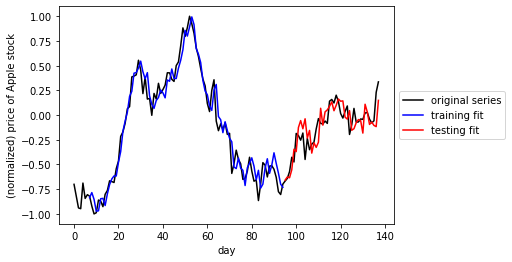

In [44]:
### Plot everything - the original series as well as predictions on training and testing sets
import matplotlib.pyplot as plt
%matplotlib inline

# plot original series
plt.plot(dataset,color = 'k')

# plot training set prediction
split_pt = train_test_split + window_size 
plt.plot(np.arange(window_size,split_pt,1),train_predict,color = 'b')

# plot testing set prediction
plt.plot(np.arange(split_pt,split_pt + len(test_predict),1),test_predict,color = 'r')

# pretty up graph
plt.xlabel('day')
plt.ylabel('(normalized) price of Apple stock')
plt.legend(['original series','training fit','testing fit'],loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

**Note:** you can try out any time series for this exercise!  If you would like to try another see e.g., [this site containing thousands of time series](https://datamarket.com/data/list/?q=provider%3Atsdl) and pick another one!